According to https://cyrillagger.github.io/scDiffCom/articles/scDiffCom-vignette.html

In [2]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(stringr)
  library(purrr)
  library(ggplot2)
  library(forcats)
  library(circlize)
  library(scDiffCom)
  library(tidyverse)
  library(future)
})

set.seed(123)

# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
#file_name <- "gated_ImmuneAging.rds"
#file_name <- "gated_heart_processed.rds" 
file_name <- "gated_sepsis_processed.rds" 
#file_name <- "gated_vaccine_processed.rds" 
#file_name <- "gated_our_dataset_processed.rds" 

input_file <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/gated_sepsis_processed.rds"
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/v2/scDiffCom_v2"
plot_dir <- file.path(out_dir, "plots")

dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(plot_dir, recursive = TRUE, showWarnings = FALSE)

message("Output directory: ", out_dir)

options(future.globals.maxSize = 2 * 1024^3)  # allow up to 2 GB
plan(sequential)

Output directory: /nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/v2/scDiffCom_v2



https://www.nature.com/articles/s43587-023-00514-x
scDiffCom includes a collection of approximately 5000 curated LRIs that they retrieved from 7 publicly available resources (CellChat, CellPhoneDB, CellTalkDB, Natmi/connectomeDB2020, ICELLNET, NicheNet, SingleCellSignalR).

1. Collection of LRIs
- kept only curated interactions
- converted human genes to mouse orthologs for human-only resources
- includes both simple (single-gene ligand with single-gene receptor) and complex interactions (heteromeric ligands or receptors, e.g. Col3a1:Itga1-Itgb1)
- 4785 human LRIs (3648 simple, 1137 complex)

2. Functional annotation of LRIs
- associtaed GO terms to each interaction in a way that conveys biological meaning related as much as possible to interaction itself rather than to each gene independently

3. Differential cell-cell communication analysis with scDiffCom
- considers all possible interactions between each cell-type pair, based on LRIs described in the previous subsection (= CCIs)
- each CCI is then assigned a score (independently in each condition) based on average expression of genes across respective cells
    - CCI score = typical interaction that would occur between 2 cells randomly picked from pool of emitter and receiver cells
    - advantage: score does not depend on number of cells captured (cell number affects confidence/variance of estimate but not scale of score)
    - limitation: inability to account for absolute communication (does not know number of sender & receiver cells) across all cells & to account for potential changes in cell compositiion

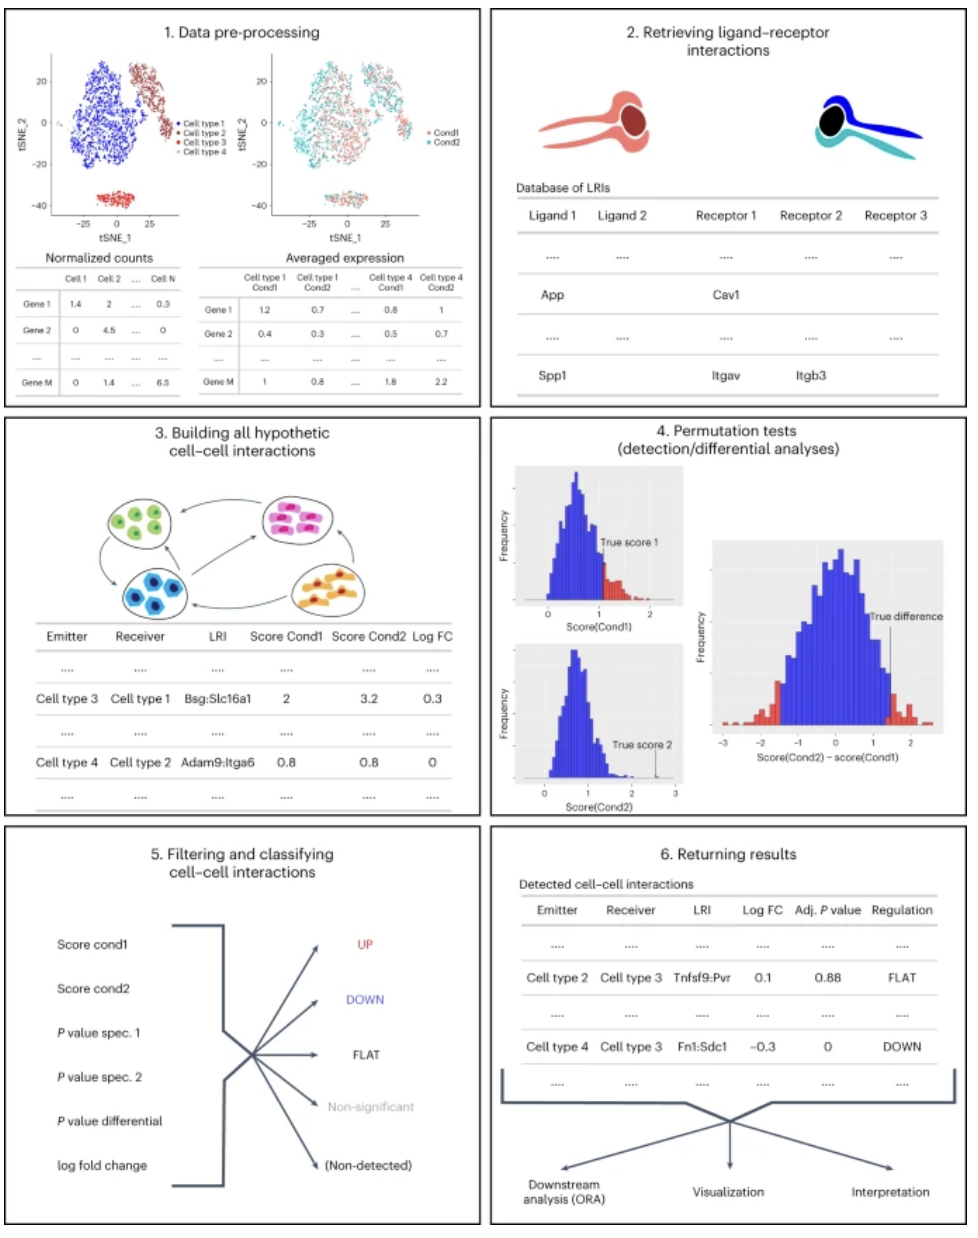

Workflow
1. Aggregate read counts/UMIs by cell types and conditions (pseudobulking?)
2. (also step 3) Genes joined with database of LRIs to build all potential CCIs that can occur between cell types
4. Statistical permutation tests are then performed to evaluate biological significance of each CCI & its differential expression
    - Biological relevance of each CCI: not lowly expressed, specific (defined by CellPhoneDB), large enough CCI score (compared to other remaining CCIs)
    - Permuation tests shuffle cell-type annotation attached to each cell to estimate how specific to a given emitter-receiver cell-type pair a particular LRI is
    - Another permutation tets that tests if score of each CCI significantly changes between 2 conditions of interest (randomly exchanging condiiton label of each cell to see whether diff between CCI scores of each condition is different from zero)
    - Permutation tests are distribution independent, applicable to unbalanced & low sample size scenarios
5. Classified based on several computed variables (scores, pvals, log-fold change)
    - 4 categories: upregulated (UP), downregulated (DOWN), stable (FLAT), non-significant (NSC)

ORA (over-representation analysis)
- typical: we can detect several thousands of CCIs in a single tissue
- ORA extracts dominant differential patterns
- evaluate frequent patterns in categorical data (particular feature of CCIs (e.g. GO term T cell differentiation) more frequent in upregulated CCIs compared to all other CCIs)
- 2 × 2 contingency table (upregulated/not upregulated versus annotated/not annotated) + Fishers exact test 2-sided
- for every CCI feature (all GO terms, KEGG pathways, LRIs, ligands, receptors and cell types) and classes (UP, DOWN and FLAT)
- OR + pval adjusted benjamini hochberg
- ORA score 
    - OR score = odds ratio from Fishers exact test
    - pval = enrichment p value
    - ORA score is high when a feature is strongly overrepresented & statistically significant
    
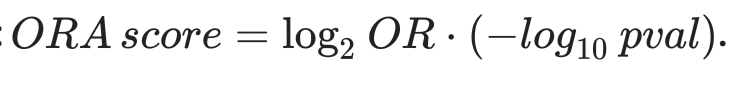

# 1. Load & Prep Data

In [3]:
seurat_obj <- readRDS(input_file)

DefaultAssay(seurat_obj)
ncol(seurat_obj)
nrow(seurat_obj)
colnames(seurat_obj@meta.data)

[1] "RNA"

[1] 285043

[1] 37487

[1] "orig.ident"                             
 [2] "nCount_RNA"                             
 [3] "nFeature_RNA"                           
 [4] "nCount_ADT"                             
 [5] "nFeature_ADT"                           
 [6] "sample"                                 
 [7] "donor_id"                               
 [8] "cell_barcodes"                          
 [9] "scRNA.seq"                              
[10] "TCR"                                    
[11] "BCR"                                    
[12] "CITE.seq"                               
[13] "Bulk.RNA.seq"                           
[14] "Olink.proteomics"                       
[15] "Gender"                                 
[16] "Age"                                    
[17] "Sample.Collection.Date"                 
[18] "Sample.Collection.Site"                 
[19] "Group"                                  
[20] "Sepsis.Infection.Source"                
[21] "Ethnicity"                              
[22] "Chronic.comorbidity.None"               
[23] "Cardiovascular.compromise"              
[24] "COPD"                                   
[25] "Hypertension"                           
[26] "Diabetes"                               
[27] "Respiratory.insufficiency"              
[28] "Renal.insufficiency"                    
[29] "Tuberculosis"                           
[30] "Length.of.ICU.stay.days"                
[31] "Length.of.hospital.stay.days"           
[32] "X14.day.mortality..Deceased.1.Living.0."
[33] "X28.day.mortality..Deceased.1.Living.0."
[34] "X90.day.mortality..Deceased.1.Living.0."
[35] "Gram.positive.bacteria"                 
[36] "Gram.negative.bacteria"                 
[37] "Virus"                                  
[38] "Fungi"                                  
[39] "Microbiology.laboratory..Unknown"       
[40] "SOFA.score"                             
[41] "Shock"                                  
[42] "Organ.failure"                          
[43] "Mechanical.ventilation"                 
[44] "percent.mt"                             
[45] "percent.ribo"                           
[46] "percent.hb"                             
[47] "mt_outlier_all"                         
[48] "is_outlier_RNA"                         
[49] "is_outlier_protein"                     
[50] "is_outlier"                             
[51] "scDblFinder.class"                      
[52] "scDblFinder.score"                      
[53] "RNA_snn_res.0.8"                        
[54] "seurat_clusters"                        
[55] "RNA_snn_res.0.25"                       
[56] "RNA.weight"                             
[57] "ADT.weight"                             
[58] "leiden_0.8_totalVI"                     
[59] "leiden_0.25_totalVI"                    
[60] "celltype_full"                          
[61] "lineage"                                
[62] "pla_status"                             
[63] "celltype"

# 2. Run default analysis

Several permutation tests are performed to assess significance of both specificity & differential expression of each potential CCI. 1000 permutations are done by default (fast & sufficient). Running the analysis only requires to specify the species, names of columns where cell-type annotation & pairwise condition are stored + explicit names of 2 conditions.

In [4]:
scdiffcom_object <- run_interaction_analysis(
  seurat_object = seurat_obj,
  LRI_species = "human",
  seurat_celltype_id = "lineage",
  seurat_condition_id = list(
    column_name = "pla_status",
    cond1_name = "platelet-free", #log(score(cond2_name) / score(cond1_name))
    cond2_name = "PLA"
  )
)

Extracting data from assay 'RNA' and layer 'data' (assuming normalized log1p-transformed data).

Converting normalized data from log1p-transformed to non-log1p-transformed.

Input data: 37487 genes, 163329 cells and 6 cell-types.

Input ligand-receptor database: 4785 human interactions.
Number of LRIs that match to genes present in the dataset: 4751.

Type of analysis to be performed: differential analysis between platelet-free and PLA cells.

Total number of potential cell-cell interactions (CCIs): 171036 (6 * 6 * 4751).

Performing permutation analysis (1000 iterations by batches of 1000) on 6950 potential CCIs.

Performing batch 1 of 1.

Filtering and cleaning 'raw' CCIs.

Returning 3818 detected CCIs.

Performing over-representation analysis on the categories: LRI, LIGAND_COMPLEX, RECEPTOR_COMPLEX, ER_CELLTYPES, EMITTER_CELLTYPE, RECEIVER_CELLTYPE, GO_TERMS, KEGG_PWS.

Successfully returning final scDiffCom object.



Why do we swap cond1 and cond2?
- A = condition 1
- B = condition 2
- logFC = log(score in cond2 / score in cond1)
- cond1_name = "platelet-free", cond2_name = "PLA" gives: logFC = log(PLA / platelet-free)
- positive logFC means: CCI score is higher in PLA

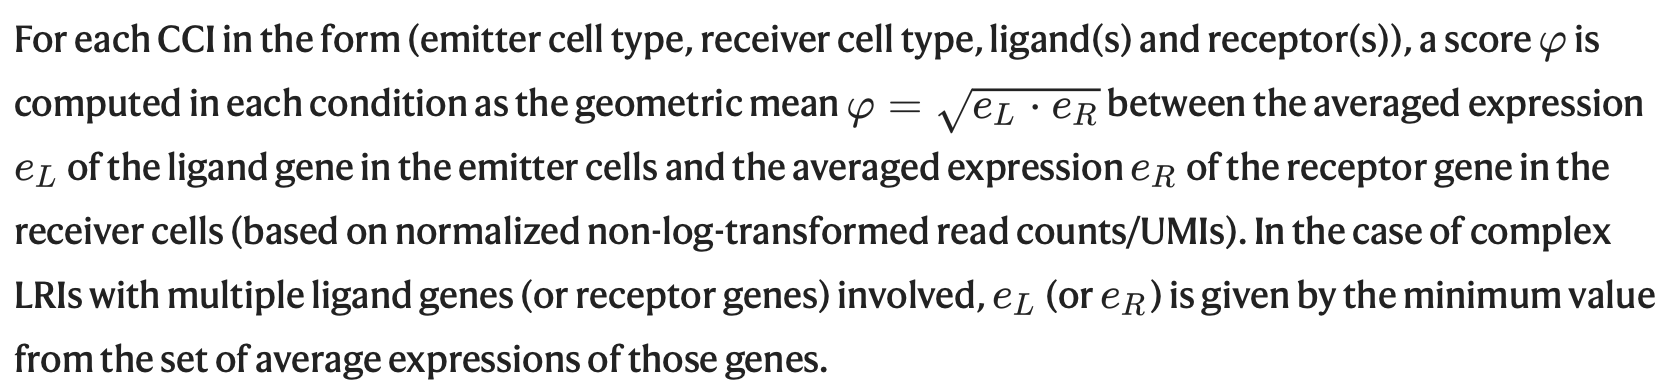

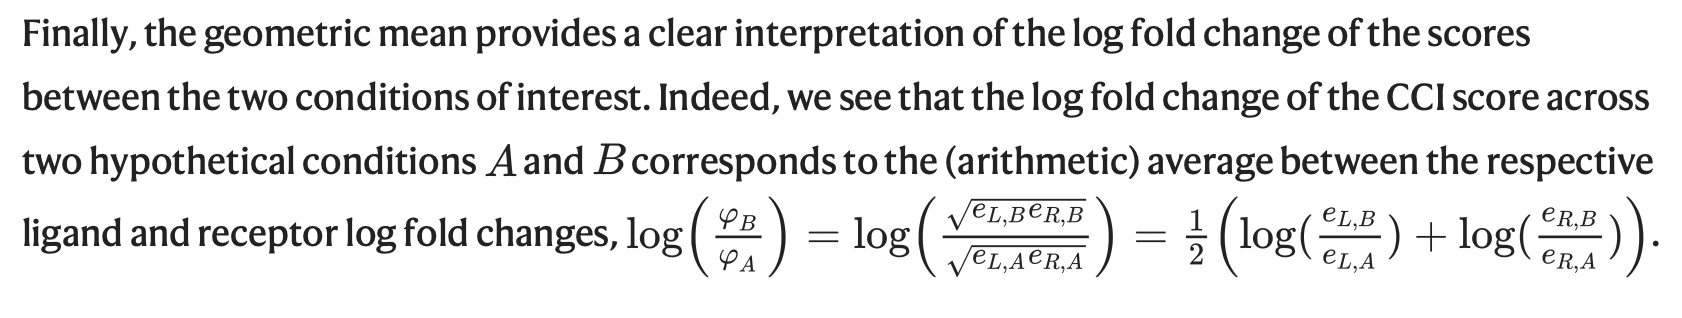

In [5]:
scdiffcom_object

An object of class scDiffCom with name scDiffCom_object
Analysis performed: differential analysis between platelet-free and PLA cells
3818 detected CCIs across 6 cell types
Over-representation results for LRI, LIGAND_COMPLEX, RECEPTOR_COMPLEX, ER_CELLTYPES, EMITTER_CELLTYPE, RECEIVER_CELLTYPE, GO_TERMS, KEGG_PWS

# 2. Explore the results

In [6]:
# Retrieve and display all detected CCIs
CCI_detected <- GetTableCCI(scdiffcom_object, type = "detected", simplified = TRUE)

# Number of CCIs per regulation type
table(CCI_detected$REGULATION)

# Retrieve the ORA results
ORA_results <- GetTableORA(scdiffcom_object, categories = "all", simplified = TRUE)

# Categories available
names(ORA_results)


DOWN FLAT   UP 
  83 3200  535 

[1] "LRI"               "LIGAND_COMPLEX"    "RECEPTOR_COMPLEX" 
[4] "ER_CELLTYPES"      "EMITTER_CELLTYPE"  "RECEIVER_CELLTYPE"
[7] "GO_TERMS"          "KEGG_PWS"

In [8]:
str(CCI_detected)

Classes ‘data.table’ and 'data.frame':	3818 obs. of  19 variables:
 $ CCI                          : chr  "B cells_B cells_ADAM10:NOTCH2" "B cells_B cells_ADAM15:ITGB3" "B cells_B cells_ADAM28:ITGA4" "B cells_B cells_APP:APLP2" ...
 $ ER_CELLTYPES                 : chr  "B cells_B cells" "B cells_B cells" "B cells_B cells" "B cells_B cells" ...
 $ LRI                          : chr  "ADAM10:NOTCH2" "ADAM15:ITGB3" "ADAM28:ITGA4" "APP:APLP2" ...
 $ NCELLS_EMITTER_platelet-free : int  20788 20788 20788 20788 20788 20788 20788 20788 20788 20788 ...
 $ NCELLS_EMITTER_PLA           : int  488 488 488 488 488 488 488 488 488 488 ...
 $ NCELLS_RECEIVER_platelet-free: int  20788 20788 20788 20788 20788 20788 20788 20788 20788 20788 ...
 $ NCELLS_RECEIVER_PLA          : int  488 488 488 488 488 488 488 488 488 488 ...
 $ CCI_SCORE_platelet-free      : num  0.7309 0.0488 1.6785 0.5802 9.5311 ...
 $ CCI_SCORE_PLA                : num  0.949 0.709 1.03 1.647 10.723 ...
 $ P_VALUE_platelet-free     

# 3. Plots

### Volcano Plot

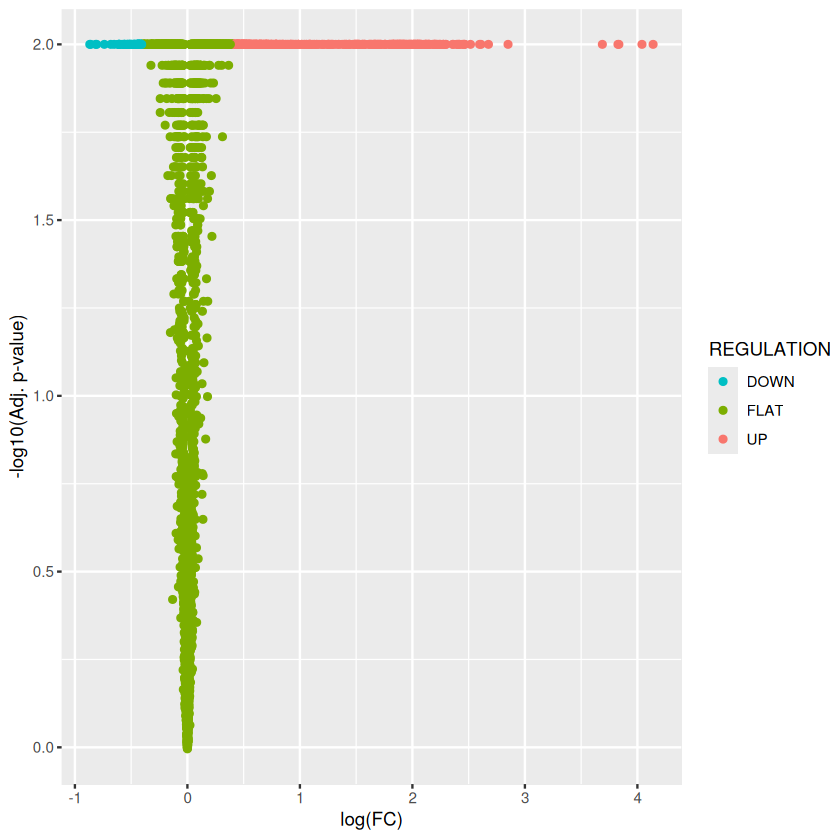

In [9]:
ggplot(
  CCI_detected,
  aes(
    x = LOGFC,
    y = -log10(BH_P_VALUE_DE + 1E-2),
    colour = REGULATION
  )
) +
  geom_point() +
  scale_colour_manual(
    values = c(
      "UP" = "#F8766D",
      "DOWN" = "#00BFC4",
      "FLAT" = "#7CAE00",
      "NSC" = "grey70"
    )
  ) +
  xlab("log(FC)") +
  ylab("-log10(Adj. p-value)")

### Dot plots of over-represented terms

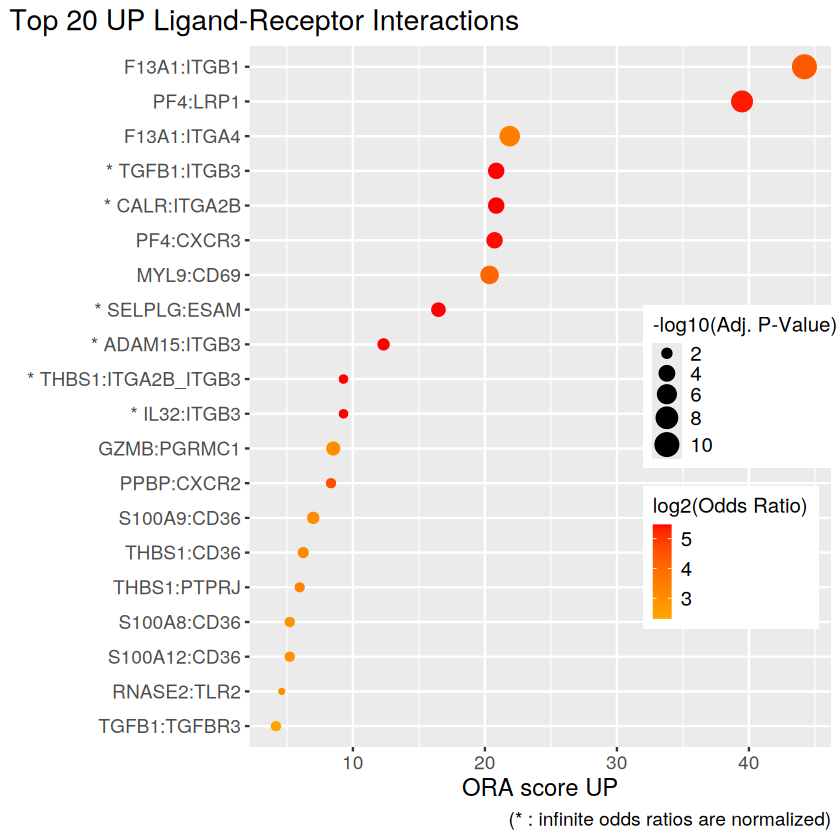

In [10]:
# Plot the most over-represented up-regulated LRIs
# PlotORA returns a ggplot object that you can further optimize (e.g. here to place the legend)
PlotORA(
  object = scdiffcom_object,
  category = "LRI",
  regulation = "UP"
) + theme(
  legend.position = c(0.85, 0.4),
  legend.key.size = unit(0.4, "cm")
)

Inifinite odds ratio normalized = 2x2 ORA contingency table had a zero in one cell.

e.g.
|                      | Has F13A1:ITGB1 | Does not have F13A1:ITGB1 |
|----------------------|----------------:|--------------------------:|
| UP CCIs              | 10              | 500                       |
| Not-UP CCIs          | 0               | 3000                      |

=> interpretation: this LRI appears in UP-regulated CCIs,
but does not appear at all in the comparison/background group
=> scDiffCom replaces with large finite value

### Creating similar plots as for Liana+

Split CCI_detected table into similar structure.
ER_CELLTYPES = "B cells_B cells"
LRI          = "ADAM10:NOTCH2"

In [11]:
scdiff_plot <- CCI_detected %>%
  as_tibble() %>%
  tidyr::separate(
    ER_CELLTYPES,
    into = c("source", "target"),
    sep = "_",
    remove = FALSE
  ) %>%
  tidyr::separate(
    LRI,
    into = c("ligand", "receptor"),
    sep = ":",
    remove = FALSE
  ) %>%
  mutate(
    lineage_pair = paste(source, target, sep = " → "),
    interaction = paste(ligand, receptor, sep = " → "),

    direction = case_when(
      REGULATION == "UP" ~ "PLA-up",
      REGULATION == "DOWN" ~ "platelet-free-up",
      REGULATION == "FLAT" ~ "flat",
      REGULATION == "NSC" ~ "not significant",
      TRUE ~ as.character(REGULATION)
    ),

    score_signed = LOGFC,
    score_abs = abs(LOGFC),
    padj = BH_P_VALUE_DE
  )

In [12]:
scdiff_sig <- scdiff_plot %>%
  filter(direction %in% c("PLA-up", "platelet-free-up"))

In [13]:
scdiff_plot %>%
  count(direction)

scdiff_sig %>%
  count(direction)

direction,n
<chr>,<int>
PLA-up,535
flat,3200
platelet-free-up,83


direction,n
<chr>,<int>
PLA-up,535
platelet-free-up,83


### 1. Global distribution

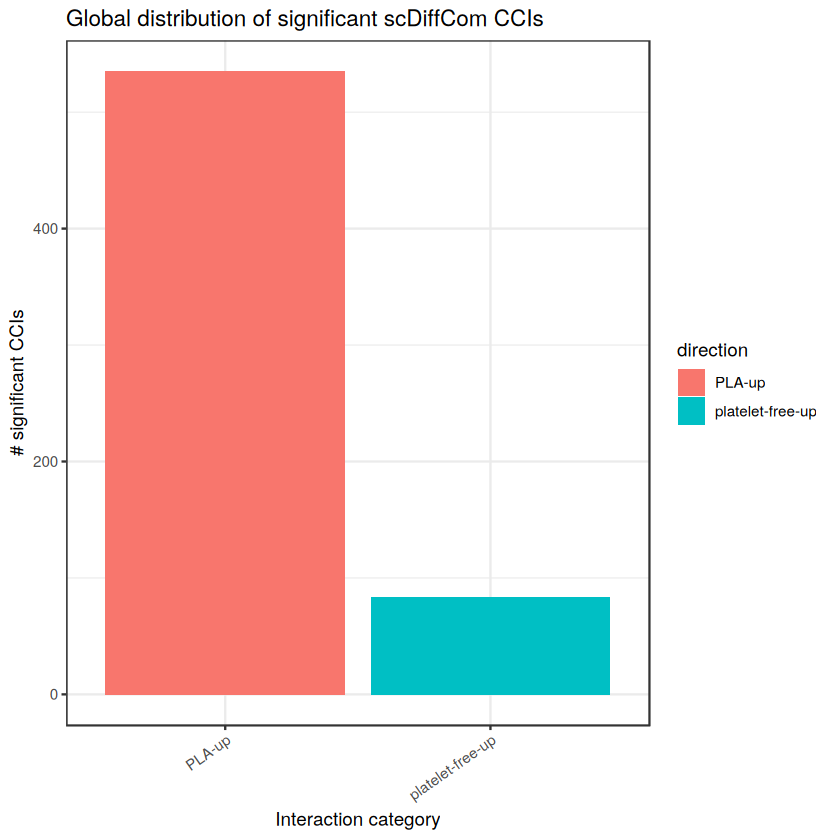

In [14]:
ggplot(scdiff_sig, aes(x = direction, fill = direction)) +
  geom_bar() +
  theme_bw() +
  scale_fill_manual(
    values = c(
      "PLA-up" = "#F8766D",
      "platelet-free-up" = "#00BFC4"
    )
  ) +
  labs(
    title = "Global distribution of significant scDiffCom CCIs",
    x = "Interaction category",
    y = "# significant CCIs"
  ) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

### 2. Direction by lineage pair

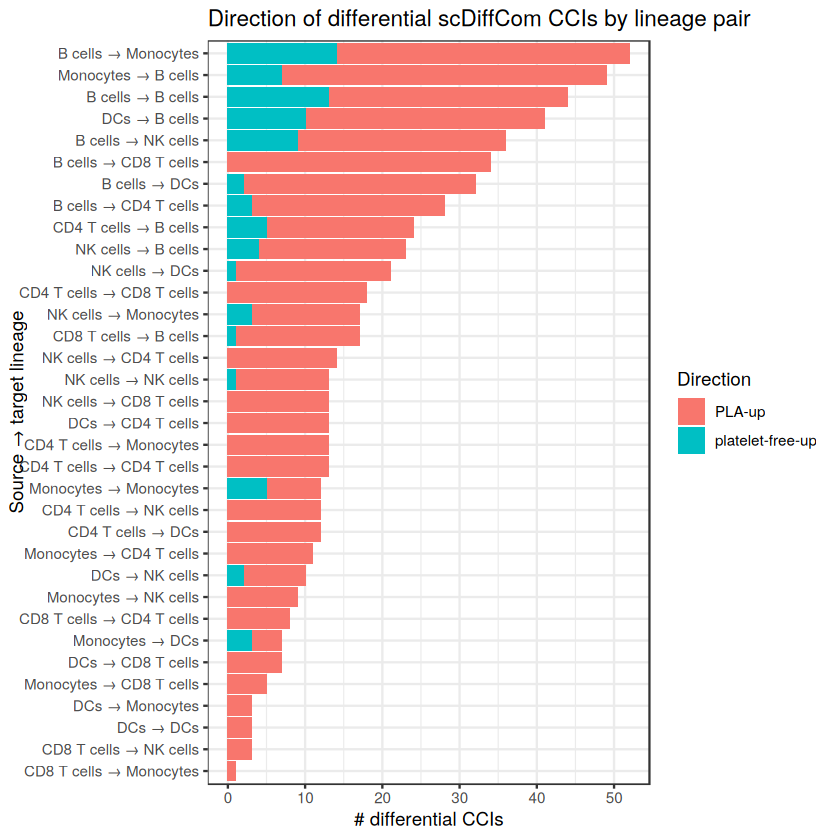

In [15]:
pair_counts_scdiff <- scdiff_sig %>%
  dplyr::count(lineage_pair, direction) %>%
  dplyr::group_by(lineage_pair) %>%
  dplyr::mutate(total = sum(n)) %>%
  dplyr::ungroup() %>%
  dplyr::arrange(desc(total)) %>%
  dplyr::mutate(lineage_pair = fct_reorder(lineage_pair, total))

ggplot(pair_counts_scdiff, aes(x = n, y = lineage_pair, fill = direction)) +
  geom_col() +
  theme_bw() +
  scale_fill_manual(
    values = c(
      "PLA-up" = "#F8766D",
      "platelet-free-up" = "#00BFC4"
    )
  ) +
  labs(
    title = "Direction of differential scDiffCom CCIs by lineage pair",
    x = "# differential CCIs",
    y = "Source → target lineage",
    fill = "Direction"
  )

### 3. Net direction heatmap

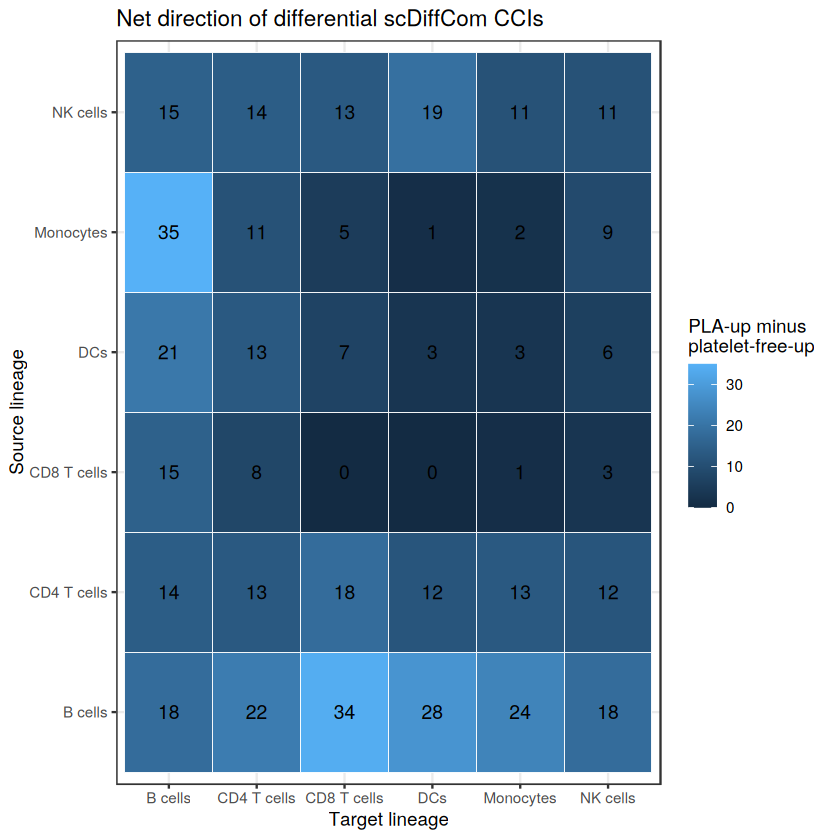

In [16]:
net_direction_scdiff <- scdiff_sig %>%
  dplyr::count(source, target, direction) %>%
  tidyr::complete(
    source,
    target,
    direction = c("PLA-up", "platelet-free-up"),
    fill = list(n = 0)
  ) %>%
  tidyr::pivot_wider(
    names_from = direction,
    values_from = n,
    values_fill = 0
  ) %>%
  dplyr::mutate(
    net = `PLA-up` - `platelet-free-up`
  )

ggplot(net_direction_scdiff, aes(x = target, y = source, fill = net)) +
  geom_tile(color = "white") +
  geom_text(aes(label = net), size = 4) +
  theme_bw() +
  labs(
    title = "Net direction of differential scDiffCom CCIs",
    x = "Target lineage",
    y = "Source lineage",
    fill = "PLA-up minus\nplatelet-free-up"
  )

### 4. Most recurrent scDiffCom LR pairs

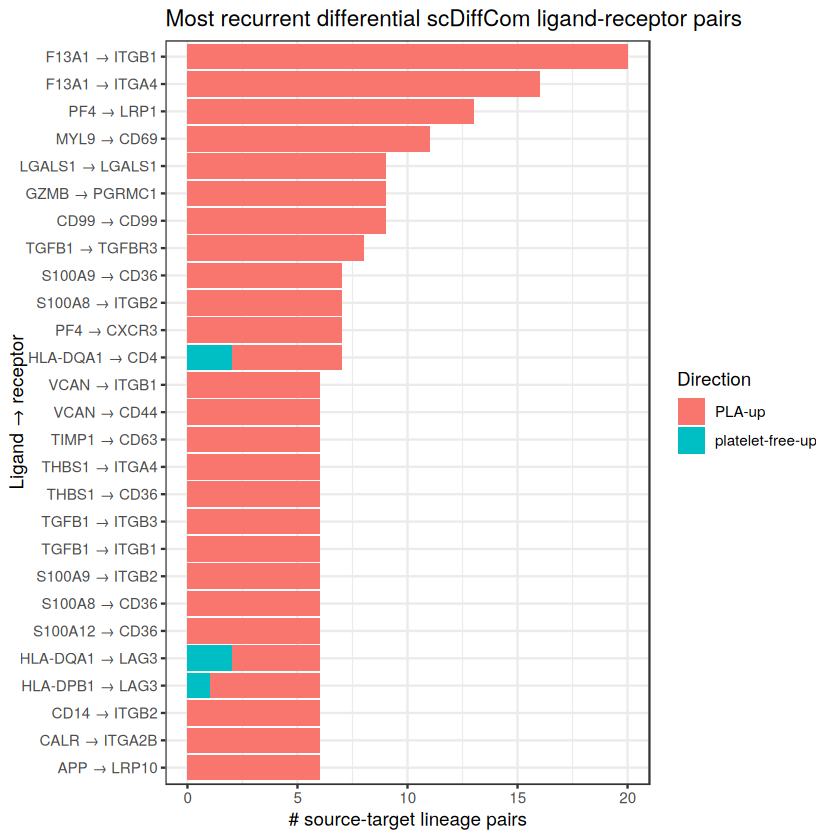

In [17]:
top_recurrent_scdiff <- scdiff_sig %>%
  dplyr::count(interaction, direction, name = "n_lineage_pairs") %>%
  dplyr::group_by(interaction) %>%
  dplyr::mutate(total = sum(n_lineage_pairs)) %>%
  dplyr::ungroup() %>%
  dplyr::slice_max(total, n = 25) %>%
  dplyr::mutate(interaction = fct_reorder(interaction, total))

ggplot(top_recurrent_scdiff, aes(x = n_lineage_pairs, y = interaction, fill = direction)) +
  geom_col() +
  theme_bw() +
  scale_fill_manual(
    values = c(
      "PLA-up" = "#F8766D",
      "platelet-free-up" = "#00BFC4"
    )
  ) +
  labs(
    title = "Most recurrent differential scDiffCom ligand-receptor pairs",
    x = "# source-target lineage pairs",
    y = "Ligand → receptor",
    fill = "Direction"
  )

### 5. Top scDiffCom CCIs per lineage pair

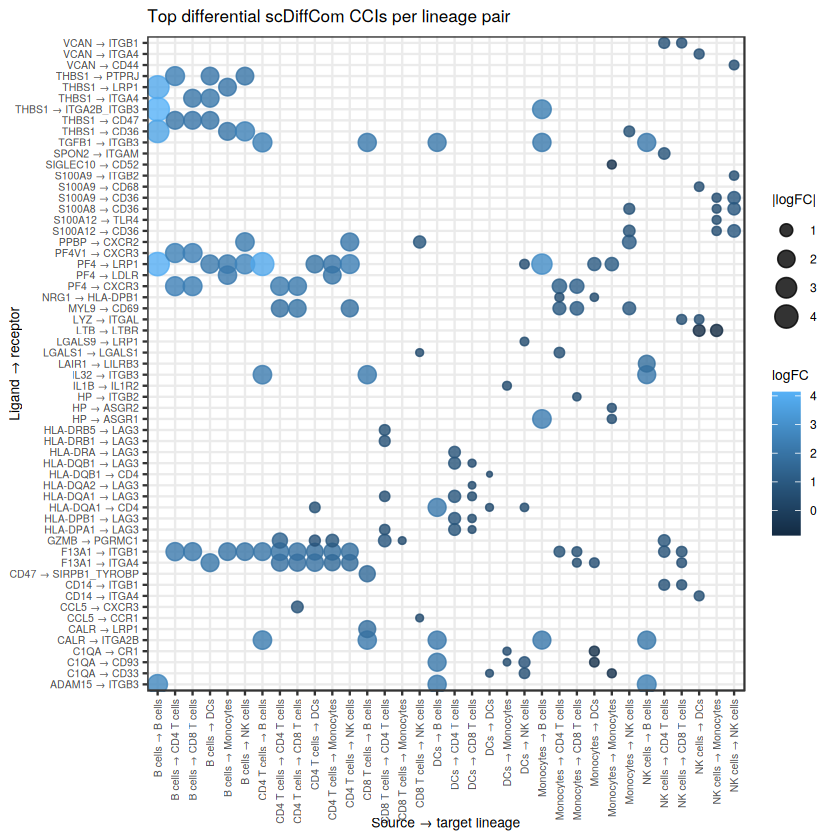

In [18]:
top_scdiff_per_pair <- scdiff_sig %>%
  group_by(lineage_pair) %>%
  slice_max(score_abs, n = 5, with_ties = FALSE) %>%
  ungroup()

ggplot(
  top_scdiff_per_pair,
  aes(
    x = lineage_pair,
    y = interaction,
    size = score_abs,
    color = score_signed
  )
) +
  geom_point(alpha = 0.8) +
  theme_bw() +
  labs(
    title = "Top differential scDiffCom CCIs per lineage pair",
    x = "Source → target lineage",
    y = "Ligand → receptor",
    size = "|logFC|",
    color = "logFC"
  ) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
    axis.text.y = element_text(size = 6),
    axis.title.x = element_text(size = 8),
    axis.title.y = element_text(size = 8),
    plot.title = element_text(size = 10),
    legend.title = element_text(size = 8),
    legend.text = element_text(size = 7)
  )